# 05b – Tuned gradient boosting: Secondary Mushroom

**Worked on by:** Andreas Schellekens (model choice, native missing-value handling, search space, threshold, test evaluation, deployable pipeline)

> **GenAI disclosure:** the first version of this notebook was drafted with the help of Claude Code (AI assistant), based on the decisions in `01_eda.ipynb` to `05a_model_random_forest.ipynb`. All steps were reviewed by the team; we must be able to explain every cell ourselves.

## 1. Setup & loading

Gradient boosting is the second tree ensemble from the top of the PyCaret comparison (LightGBM, CV AUC 0.816, notebook 04). We tune it with the same protocol as the random forest in `05a_model_random_forest.ipynb`: our own search space, ROC-AUC with 5-fold CV on the training set, a decision threshold for 90% recall on poisonous mushrooms chosen on the validation set, and one evaluation on the same test set.

Imports, paths and constants. `LOKY_MAX_CPU_COUNT` silences a harmless joblib warning on Windows and must be set before scikit-learn is imported.

In [1]:
import os
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OrdinalEncoder

DATA_DIR = Path("Data")
MODEL_DIR = Path("models")
MODEL_PATH = MODEL_DIR / "mushroom_gradient_boosting.joblib"
MODEL_INFO_PATH = MODEL_DIR / "mushroom_gradient_boosting.json"
METRICS_PATH = MODEL_DIR / "metrics.csv"

NOTEBOOK = "05b_model_gradient_boosting"
RANDOM_STATE = 42
TARGET = "is_poisonous"
RECALL_TARGET = 0.90  # same target as the random forest (05a, section 5)
SPLITS = ["train", "validation", "test"]
NUM_COLS = ["cap_diameter", "stem_height", "stem_width", "has_stem"]
CAT_COLS = ["spore_print_color", "gill_color", "habitat", "season", "ring_type", "cap_shape", "stem_surface"]
CLASS_PALETTE = {"edible": "#2a9d8f", "poisonous": "#e76f51"}  # same colours as the EDA


def data_path(split, kind):
    # Files made by 02_data_preparation.ipynb, e.g. Data/validation/mushroom_cleaned_validation.csv
    return DATA_DIR / split / f"mushroom_{kind}_{split}.csv"

We load the data in **two forms**, for the two variants in section 3, each for the train, validation and test set (one folder per set):
- the **prepared** files from notebook 02 (imputed, `log1p` + standardised, one-hot: 64 columns), as NumPy arrays like in 05a;
- the **cleaned** files: readable categories and numerical `NaN` still empty (11 columns).

Both forms contain exactly the same rows in the same order (same `row_id`s); the `assert`s check this. As in 05a, the training set is used for the search, the validation set for checks and the threshold, and the test set once at the end.

In [2]:
prepared = {split: pd.read_csv(data_path(split, "prepared"), index_col="row_id") for split in SPLITS}
cleaned = {split: pd.read_csv(data_path(split, "cleaned"), index_col="row_id") for split in SPLITS}
for split in SPLITS:
    assert cleaned[split].index.equals(prepared[split].index)
    assert ((cleaned[split]["class"] == "poisonous").astype(int) == prepared[split][TARGET]).all()

X_train_prep, X_val_prep, X_test_prep = (prepared[s].drop(columns=TARGET).to_numpy() for s in SPLITS)
X_train_native, X_val_native, X_test_native = (cleaned[s][NUM_COLS + CAT_COLS] for s in SPLITS)
y_train, y_val, y_test = (prepared[s][TARGET] for s in SPLITS)

print(f"Prepared: {X_train_prep.shape[1]} columns  |  cleaned: {X_train_native.shape[1]} columns")
print(f"Rows – train: {len(y_train)}  |  validation: {len(y_val)}  |  test: {len(y_test)}")
print("Missing values in the cleaned training rows:", X_train_native.isna().sum()[lambda s: s > 0].to_dict())

Prepared: 64 columns  |  cleaned: 11 columns
Rows – train: 3500  |  validation: 750  |  test: 750
Missing values in the cleaned training rows: {'cap_diameter': 1396, 'stem_height': 705, 'stem_width': 265, 'has_stem': 42}


## 2. Why gradient boosting, and why `HistGradientBoostingClassifier`?

**Boosting vs. the random forest.** A random forest trains many deep trees *independently* and averages them: averaging reduces the variance of the individual trees. Gradient boosting trains small trees **one after the other**: every new tree is fitted to the errors (more precisely, the gradient of the loss) of all previous trees together, and its contribution is multiplied by a small **learning rate**. It reduces the bias step by step. On many tabular datasets boosting is the strongest model family, so it is the natural competitor for the forest.

**Why scikit-learn's `HistGradientBoostingClassifier`** (HGB) instead of LightGBM:
- It is the same kind of algorithm: HGB was modelled on LightGBM (numerical values are binned into at most 255 bins, which makes finding a split fast).
- It is part of scikit-learn, so the API needs no extra library, and it avoids the LightGBM/PyCaret DLL conflict (notebook 04, section 1).
- It handles **missing values** and **categorical features** natively, which lets us test something new (section 3).

**Paths not taken:**
- *LightGBM* itself: very similar results in PyCaret (0.816), for the reasons above not worth an extra dependency.
- *XGBoost*: the third big boosting library. We use it on AWS SageMaker (`06_model_aws.ipynb`), where it is a built-in algorithm, so we do not train it here as well.
- *scikit-learn's older `GradientBoostingClassifier`*: slower, no missing-value support, and weaker in PyCaret (0.769).
- *CatBoost*: not installed; its main advantage (categorical features) is covered by HGB's native categorical support.

## 3. Two ways to feed the data

HGB can use the data in two ways, and we test both:

1. **prepared**: the 64 columns from our preprocessor (median imputation, one-hot encoding), like every other model.
2. **native**: the cleaned columns without imputation and without one-hot encoding.
   - *Missing values*: at every split, HGB learns on which side the rows with a missing value should go, based on what reduces the loss most. A missing `cap_diameter` is then not "6.1 cm" (the median) but its own situation.
   - *Categoricals*: an `OrdinalEncoder` turns every category into an integer code (e.g. `woods` → 7), and `categorical_features` tells HGB that these codes have no order. A split can then put *any group* of categories on one side (e.g. {woods, paths} vs. the rest) instead of one one-hot column at a time. 11 columns instead of 64.
   - `unknown_value=np.nan`: a category the model never saw (e.g. through the API) becomes a missing value instead of an error.

The native variant is also a second, independent answer to a question from notebook 02 (section 9.2): **does median imputation throw information away?** If the model that handles the gaps itself does not score better, the median was fine. (If it does, the gain can come from the gaps *or* from the native categories: this variant changes both at once.)

First both variants with default settings, with the same 5 folds as before.

In [3]:
native_model = Pipeline([
    ("encode", ColumnTransformer([
        ("num", "passthrough", NUM_COLS),
        ("cat", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=np.nan), CAT_COLS),
    ])),
    ("model", HistGradientBoostingClassifier(
        categorical_features=list(range(len(NUM_COLS), len(NUM_COLS) + len(CAT_COLS))),  # positions after encoding
        random_state=RANDOM_STATE)),
])
prepared_model = HistGradientBoostingClassifier(random_state=RANDOM_STATE)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
for name, model, X in [("prepared", prepared_model, X_train_prep), ("native", native_model, X_train_native)]:
    scores = cross_validate(model, X, y_train, cv=cv, scoring="roc_auc")["test_score"]
    print(f"Default HGB, {name:8s} – CV ROC-AUC: {scores.mean():.3f} ± {scores.std():.3f}")

Default HGB, prepared – CV ROC-AUC: 0.821 ± 0.006
Default HGB, native   – CV ROC-AUC: 0.826 ± 0.006


With default settings the native variant scores a little higher than the prepared one (0.826 vs. 0.821), both just below the default random forest (0.832, notebook 05a) and above PyCaret's LightGBM (0.816).

## 4. Hyperparameter search

| Hyperparameter | Values tried | What it controls |
|---|---|---|
| `learning_rate` | 0.01 to 0.3 (log scale) | How much every new tree corrects. Small = many small, careful steps. |
| `max_leaf_nodes` | 8 to 127 | Size of each tree (HGB grows trees leaf by leaf, like LightGBM). |
| `max_depth` | unlimited, 6, 10 | An extra limit on the depth of each tree. |
| `min_samples_leaf` | 2 to 59 | Minimum rows per leaf. Higher = less chance to fit single (possibly mislabelled) rows. |
| `l2_regularization` | 0.001 to 10 (log scale) | Penalty that shrinks the leaf values, another brake on overfitting. |
| `max_features` | 20% to 100% | Share of the features each split may consider (like in the forest), which adds randomness. |
| `class_weight` | none, `balanced` | Extra weight for the poisonous class. |

**The number of trees is not searched: early stopping chooses it.** `max_iter=1000` is only an upper limit. HGB keeps 10% of its training rows apart, and stops adding trees when the loss on those rows has not improved for 30 rounds. Every fit therefore gets as many trees as it needs for its learning rate. A small learning rate needs many trees, which is why these two cannot be tuned separately.

**The same 40 combinations for both variants.** With the same `random_state`, `RandomizedSearchCV` draws exactly the same 40 combinations for both, and scores them on the same 5 folds. That makes it a paired comparison: every combination is tried once with the prepared and once with the native data.

HGB already uses all CPU cores for a single fit, so the search runs the combinations one after the other (`n_jobs=1`). Both searches together take a few minutes.

In [4]:
search_space = {
    "learning_rate": loguniform(0.01, 0.3),
    "max_leaf_nodes": randint(8, 128),
    "max_depth": [None, 6, 10],
    "min_samples_leaf": randint(2, 60),
    "l2_regularization": loguniform(1e-3, 10),
    "max_features": uniform(0.2, 0.8),  # uniform(loc, scale): between 0.2 and 1.0
    "class_weight": [None, "balanced"],
}
early_stopping = {"max_iter": 1000, "early_stopping": True, "validation_fraction": 0.1, "n_iter_no_change": 30}

searches = {
    "prepared": RandomizedSearchCV(clone(prepared_model).set_params(**early_stopping), search_space,
                                   n_iter=40, scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=1),
    "native": RandomizedSearchCV(clone(native_model).set_params(**{f"model__{k}": v for k, v in early_stopping.items()}),
                                 {f"model__{k}": v for k, v in search_space.items()},
                                 n_iter=40, scoring="roc_auc", cv=cv, random_state=RANDOM_STATE, n_jobs=1),
}
searches["prepared"].fit(X_train_prep, y_train)
searches["native"].fit(X_train_native, y_train)

scores = pd.DataFrame({name: s.cv_results_["mean_test_score"] for name, s in searches.items()})
params = pd.DataFrame(searches["prepared"].cv_results_["params"])
assert params.equals(pd.DataFrame(searches["native"].cv_results_["params"]).rename(columns=lambda c: c.removeprefix("model__")))
results = params.join(scores).sort_values("native", ascending=False)
for name, s in searches.items():
    print(f"Best CV ROC-AUC, {name:8s}: {s.best_score_:.3f}")
results.head(8).round(4)

Best CV ROC-AUC, prepared: 0.818
Best CV ROC-AUC, native  : 0.821


,class_weight,l2_regularization,learning_rate,max_depth,max_features,max_leaf_nodes,min_samples_leaf,prepared,native
36,None,3.3927,0.0190,NaN,0.4794,55,17,0.8170,0.8215
0,None,1.5352,0.0187,NaN,0.6775,90,24,0.8127,0.8198
20,None,1.0525,0.0218,10.0,0.4318,93,29,0.8091,0.8186
18,None,0.6961,0.0146,NaN,0.3614,103,40,0.8048,0.8185
11,None,0.0359,0.0252,NaN,0.6694,96,46,0.8026,0.8183
37,None,2.6625,0.0396,NaN,0.7136,82,50,0.7978,0.8180
3,None,0.0534,0.0269,10.0,0.5199,99,17,0.8146,0.8179
31,None,0.0040,0.0563,NaN,0.8867,66,37,0.8028,0.8176


The same comparison for all 40 combinations: each dot is one combination, scored with the prepared data (x) and with the native data (y). Dots on the diagonal score the same both ways.

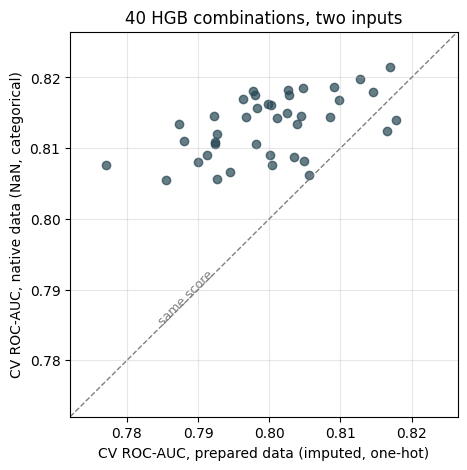

native - prepared: mean +0.0131, native better for 38 of 40 combinations


In [5]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(scores["prepared"], scores["native"], s=36, color="#264653", alpha=0.7)
lims = [scores.min().min() - 0.005, scores.max().max() + 0.005]
ax.plot(lims, lims, color="gray", ls="--", lw=1)
ax.text(lims[0] + 0.012, lims[0] + 0.013, "same score", color="gray", fontsize=9, rotation=45)
ax.set(xlim=lims, ylim=lims, xlabel="CV ROC-AUC, prepared data (imputed, one-hot)",
       ylabel="CV ROC-AUC, native data (NaN, categorical)", title="40 HGB combinations, two inputs")
ax.grid(alpha=0.3)
plt.show()

diff = scores["native"] - scores["prepared"]
print(f"native - prepared: mean {diff.mean():+.4f}, native better for {(diff > 0).sum()} of {len(diff)} combinations")

The search compared the two variants with cross-validation on the training set. As an independent check, we score the best model of each variant (refitted on all 3500 training rows) on the **validation set**, which neither search has seen. We add the **default** native model as well: in cross-validation it scored *higher* (0.826) than the best tuned combination, so the validation set has to tell whether tuning helped at all.

In [6]:
default_native = clone(native_model).fit(X_train_native, y_train)
pd.Series({"tuned, prepared": roc_auc_score(y_val, searches["prepared"].predict_proba(X_val_prep)[:, 1]),
           "tuned, native": roc_auc_score(y_val, searches["native"].predict_proba(X_val_native)[:, 1]),
           "default, native": roc_auc_score(y_val, default_native.predict_proba(X_val_native)[:, 1])},
          name="validation ROC-AUC").round(3)

tuned, prepared    0.808
tuned, native      0.819
default, native    0.814
Name: validation ROC-AUC, dtype: float64

**Interpretation**
- **Best CV scores: 0.821 (native) and 0.818 (prepared).** That is *not* better than the default settings on the same folds (0.826 and 0.821). On the validation set it is the other way round: the tuned native model scores 0.819, the default native model 0.814. Both differences (±0.005) are within the fold-to-fold standard deviation (0.006) and well within the uncertainty of 750 validation rows. The honest conclusion: **for gradient boosting, tuning gains little or nothing here**; the default is already a good model. (Contrast with the forest in 05a, where tuning gave a small but consistent gain.)
- The best combinations share a **small learning rate** (about 0.02) and **large leaves** (at least 17 rows). With small steps, early stopping adds trees until the validation loss stops improving (365 in the final model, section 5), and large leaves keep single, possibly mislabelled rows from getting a leaf of their own. That is the opposite of the forest, which works best with leaves of 1–3 rows. The reason is how the two combine their trees: boosting keeps correcting the remaining errors, so without brakes it would chase the flipped labels; the forest averages independent trees, so their individual mistakes cancel out.
- All top combinations use no class weights; as in the other notebooks, class weights barely change the ranking, and the threshold takes care of recall.
- **Native vs. prepared:** the native data is better for 38 of the 40 combinations, by 0.013 on average (the dots are above the diagonal), and also on the validation set (0.819 vs. 0.808). A likely reason: one split on a native categorical can put a whole group of categories on one side, where one-hot data needs a series of splits, one small column at a time.
- **The imputation question (notebook 02, section 9.2)** is not settled by this: the native variant changes the handling of missing values *and* of the categories at once, so we cannot tell which of the two causes the gain. In notebook 02, a better imputation (iterative) did not help the forest, which points to the categories.
- **Decision: the tuned native model.** Native beats prepared in cross-validation and on validation. Between tuned and default the scores are within the noise; we take the tuned settings because they win on the validation set, the set meant for this kind of choice, and because a small learning rate with large leaves is the safer choice with label noise.

## 5. Choosing the decision threshold

Exactly as in notebook 05a (section 5): the chosen model, trained on the training rows, predicts the **validation set**, and we take the highest threshold that still catches 90% of the poisonous validation mushrooms. The test set stays untouched.

In [7]:
best_hgb = searches["native"].best_estimator_  # the chosen variant, refitted on all training rows
p_val = best_hgb.predict_proba(X_val_native)[:, 1]


def threshold_for_recall(y_true, p, target):
    # Highest threshold whose recall is still >= target (recall only drops when the threshold rises)
    _, recall, thresholds = precision_recall_curve(y_true, p)
    return thresholds[recall[:-1] >= target].max()


def operating_point(y_true, p, threshold):
    pred = p >= threshold
    return {"threshold": threshold, "recall": recall_score(y_true, pred), "precision": precision_score(y_true, pred),
            "share_of_edible_flagged": (pred & (y_true == 0)).sum() / (y_true == 0).sum()}


threshold = threshold_for_recall(y_val, p_val, RECALL_TARGET)
points = {"default threshold 0.5": operating_point(y_val, p_val, 0.5),
          f"recall >= {RECALL_TARGET:.2f}": operating_point(y_val, p_val, threshold)}
print(f"Chosen threshold: {threshold:.3f}")
print("Trees in the final model (chosen by early stopping):", best_hgb.named_steps["model"].n_iter_)
pd.DataFrame(points).T.round(3)

Chosen threshold: 0.139
Trees in the final model (chosen by early stopping): 365


,threshold,recall,precision,share_of_edible_flagged
default threshold 0.5,0.500,0.634,0.793,0.101
recall >= 0.90,0.139,0.901,0.467,0.627


**Interpretation**
- At 0.5 the model catches 63% of the poisonous validation mushrooms (random forest: also 63%).
- The threshold for 90% recall is **0.14**, lower than the forest's 0.16. That does not make this model more careful. It uses no class weights, so its probabilities follow the real share of poisonous mushrooms (38%), while the forest's balanced class weights push its probabilities up. A threshold only means something together with its own model, which is why every model stores its own threshold.
- At 90% recall, precision is 0.47 and 63% of the edible mushrooms are flagged (forest: 0.46 and 64%): practically the same operating point.

## 6. Validation & test evaluation

The final model (chosen hyperparameters, trained on all 3500 training rows, threshold from the validation set) is evaluated **once** on the test set, at threshold 0.5 and at the chosen threshold. The validation rows are listed as well, for the model choice in `07_model_comparison.ipynb`. The `evaluate` helper is the same as in notebooks 03–05a.

In [8]:
def evaluate(name, split, y_true, p_poisonous, threshold=0.5):
    y_pred = (p_poisonous >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return {
        "model": name,
        "notebook": NOTEBOOK,
        "split": split,
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "recall_poisonous": recall_score(y_true, y_pred),
        "precision_poisonous": precision_score(y_true, y_pred, zero_division=0),
        "f1_poisonous": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, p_poisonous),
        "missed_poisonous": fn,
        "false_alarms": fp,
    }


p_test = best_hgb.predict_proba(X_test_native)[:, 1]
results = []
for split, y_split, p_split in [("validation", y_val, p_val), ("test", y_test, p_test)]:
    results.append(evaluate("gradient boosting (tuned)", split, y_split, p_split, threshold=0.5))
    results.append(evaluate(f"gradient boosting (tuned, recall {RECALL_TARGET:.2f})", split, y_split, p_split, threshold=threshold))
pd.DataFrame(results).set_index(["model", "split"]).drop(columns="notebook").round(3)

,,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
model,split,,,,,,,,
gradient boosting (tuned),validation,0.500,0.799,0.634,0.793,0.705,0.819,104,47
"gradient boosting (tuned, recall 0.90)",validation,0.139,0.573,0.901,0.467,0.615,0.819,28,292
gradient boosting (tuned),test,0.500,0.808,0.623,0.827,0.711,0.847,107,37
"gradient boosting (tuned, recall 0.90)",test,0.139,0.576,0.940,0.470,0.627,0.847,17,301


The confusion matrices at both thresholds; the bottom-left cell counts the poisonous mushrooms called edible.

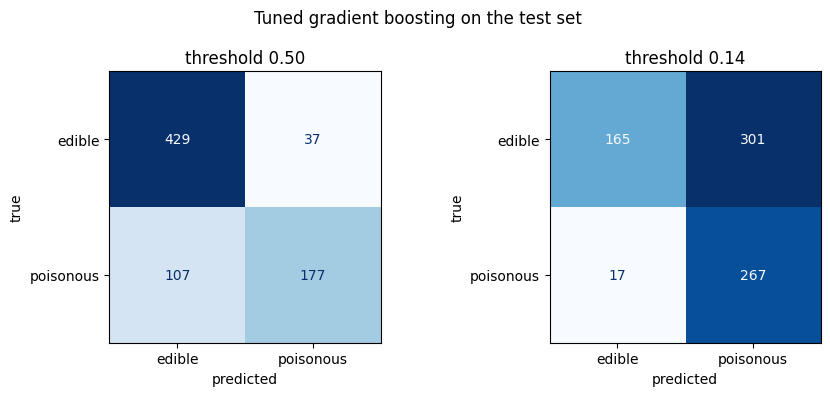

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, t in zip(axes, [0.5, threshold]):
    ConfusionMatrixDisplay.from_predictions(y_test, (p_test >= t).astype(int), display_labels=["edible", "poisonous"],
                                            cmap="Blues", colorbar=False, ax=ax)
    ax.set(title=f"threshold {t:.2f}", xlabel="predicted", ylabel="true")
    ax.grid(False)
fig.suptitle("Tuned gradient boosting on the test set")
plt.tight_layout()
plt.show()

**Interpretation**
- **At threshold 0.5:** AUC 0.847, accuracy 0.808, recall 0.62 (107 poisonous mushrooms missed, 37 false alarms). The forest on the same test set: AUC 0.842, 110 missed, 44 false alarms.
- **At threshold 0.14:** recall **0.940**: 267 of the 284 poisonous mushrooms caught, **17 missed**, with 301 false alarms (precision 0.47). The forest at its own threshold: 20 missed and 296 false alarms. As with the forest, the test recall is above the 90% chosen on validation, because the test set is a little easier than the validation set.
- These differences are 3 of 284 poisonous and 5 of 466 edible mushrooms, well within the uncertainty of a test set of 750 rows (the AUC has a standard error of about 0.015). The honest conclusion: **at our operating point, both tree ensembles are about equally good.** `07_model_comparison.ipynb` compares them on exactly the same rows with a bootstrap, which is fairer than comparing single numbers.

## 7. Saving the model for deployment

The chosen model is already a complete pipeline (ordinal encoder + HGB) that takes the cleaned, readable columns, so the API can use it exactly like the baseline and the forest: apply the cleaning of notebook 02 (sections 2–5), call `predict_proba`, and compare the probability with the threshold from the JSON file next to it. It does **not** use the preprocessor from notebook 02: the imputation and one-hot encoding are simply not needed.

The column order of the input is the same as for the other models, which we check.

In [10]:
preprocessor_columns = list(joblib.load(MODEL_DIR / "mushroom_preprocessor.joblib").feature_names_in_)
assert NUM_COLS + CAT_COLS == preprocessor_columns, "Input columns differ from the other deployable models"

joblib.dump(best_hgb, MODEL_PATH, compress=3)
model_info = {
    "model": "gradient boosting (tuned)",
    "notebook": NOTEBOOK,
    "threshold": round(float(threshold), 4),
    "threshold_rule": f"highest threshold with recall (poisonous) >= {RECALL_TARGET} on the validation set",
    "cv_roc_auc": round(float(searches["native"].best_score_), 4),
    "validation_roc_auc": round(float(roc_auc_score(y_val, p_val)), 4),
    "hyperparameters": {k.removeprefix("model__"): v.item() if hasattr(v, "item") else v  # NumPy numbers -> plain for JSON
                        for k, v in searches["native"].best_params_.items()},
    "n_trees": int(best_hgb.named_steps["model"].n_iter_),
    "input_columns": NUM_COLS + CAT_COLS,
}
MODEL_INFO_PATH.write_text(json.dumps(model_info, indent=2))
print(f"Saved {MODEL_PATH}  ({MODEL_PATH.stat().st_size / 1e3:.0f} KB)  and  {MODEL_INFO_PATH}")
print(json.dumps(model_info, indent=2))

Saved models\mushroom_gradient_boosting.joblib  (999 KB)  and  models\mushroom_gradient_boosting.json
{
  "model": "gradient boosting (tuned)",
  "notebook": "05b_model_gradient_boosting",
  "threshold": 0.139,
  "threshold_rule": "highest threshold with recall (poisonous) >= 0.9 on the validation set",
  "cv_roc_auc": 0.8215,
  "validation_roc_auc": 0.8193,
  "hyperparameters": {
    "class_weight": null,
    "l2_regularization": 3.3926993279225184,
    "learning_rate": 0.018999548501132082,
    "max_depth": null,
    "max_features": 0.47936765969012873,
    "max_leaf_nodes": 55,
    "min_samples_leaf": 17
  },
  "n_trees": 365,
  "input_columns": [
    "cap_diameter",
    "stem_height",
    "stem_width",
    "has_stem",
    "spore_print_color",
    "gill_color",
    "habitat",
    "season",
    "ring_type",
    "cap_shape",
    "stem_surface"
  ]
}


## 8. Storing the metrics

Both test rows go into the shared `models/metrics.csv`; rows of this notebook are replaced when it is run again.

In [11]:
new_rows = pd.DataFrame(results)
if METRICS_PATH.exists():
    metrics = pd.read_csv(METRICS_PATH)
    metrics = pd.concat([metrics[metrics["notebook"] != NOTEBOOK], new_rows], ignore_index=True)
else:
    metrics = new_rows
metrics.to_csv(METRICS_PATH, index=False)
metrics.round(3)

,model,notebook,split,threshold,accuracy,recall_poisonous,precision_poisonous,f1_poisonous,roc_auc,missed_poisonous,false_alarms
0,ensemble (stack: forest + boosting),05c_model_ensemble,validation,0.500,0.801,0.669,0.776,0.718,0.821,94,55
1,"ensemble (stack: forest + boosting), recall 0.90",05c_model_ensemble,validation,0.130,0.575,0.901,0.468,0.616,0.821,28,291
2,ensemble (stack: forest + boosting),05c_model_ensemble,test,0.500,0.811,0.662,0.803,0.726,0.851,96,46
3,"ensemble (stack: forest + boosting), recall 0.90",05c_model_ensemble,test,0.130,0.581,0.923,0.473,0.625,0.851,22,292
4,naive (always edible),03_model_baseline,validation,0.500,0.621,0.000,0.000,0.000,0.500,284,0
5,logistic regression (balanced),03_model_baseline,validation,0.500,0.656,0.623,0.540,0.578,0.704,107,151
6,naive (always edible),03_model_baseline,test,0.500,0.621,0.000,0.000,0.000,0.500,284,0
7,logistic regression (balanced),03_model_baseline,test,0.500,0.677,0.630,0.566,0.597,0.711,105,137
8,PyCaret random forest (default),04_model_automl,validation,0.500,0.803,0.648,0.793,0.713,0.818,100,48
9,PyCaret random forest (default),04_model_automl,test,0.500,0.785,0.606,0.778,0.681,0.838,112,49


## 9. Conclusion & next steps

- **Tuned gradient boosting:** CV AUC 0.821, validation AUC 0.819, test AUC 0.847. With the threshold of 0.14 (chosen on validation) it catches 94% of the poisonous test mushrooms (17 missed) at the cost of 301 false alarms out of 466 edible mushrooms.
- **Tuning helps little:** the default settings are as good within the noise (better in cross-validation, worse on validation). What the best settings have in common: a small learning rate with early stopping, and large leaves. Boosting needs brakes against the label noise; the random forest needs the opposite (small leaves), because its averaging already removes the noise.
- **Native missing values and categoricals** beat median imputation + one-hot (38 of 40 combinations, and on validation) and are much more robust across hyperparameters. Because both are changed at once, this does not prove that the median loses information.
- **Compared with the random forest:** about equally good at our operating point. The boosting model is much smaller (1.0 MB vs. 26 MB) and faster, a real argument for deployment. The choice is made in `07_model_comparison.ipynb`.
- **Deployable:** `models/mushroom_gradient_boosting.joblib` (encoder + HGB, takes the cleaned columns like the other models) with `models/mushroom_gradient_boosting.json` (threshold 0.139).

**Next steps**
- `05c_model_ensemble.ipynb`: combine the forest, this model and two models of other families in a heterogeneous ensemble.
- `07_model_comparison.ipynb`: all models on the same rows, uncertainty of the differences, permutation importance and error analysis.